In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pfi.utils.data import load_data, X_from_snapshots
from pfi import make_score_estimator, make_flow_estimator
from pfi.flow.interpolants import LinearInterpolant
from pfi.flow.models import CLEFlow, AdditiveFlow, MultiplicativeFlow, AutonomousODEFlow
from pfi.score import freeze_dsm_score

from examples.mpl_config import apply_mpl_config

apply_mpl_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/mnt/home/vchardes/.local/share/venvs/score/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


device(type='cuda')

In [2]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

nsamples = 6000

path = '/mnt/home/vchardes/ceph/datasets/HSC_data/10XChromiumV3_10.1038_s41467-021-27159-x_10.5281_zenodo.5291737_exvivo.h5ad'
genes = ['gata1','fli1','klf1','gata2','gfi1','gfi1b','runx1','tal1','jun','spi1','zfpm1','lmo2','etv6','erg','cebpa',\
         'meis1','sall4','myc','foxo3','zbtb7a','nanog','nfe2','stat3','mef2c']

samples, times, ind_array, cell_types = load_data(
    path=path,
    nsamples=nsamples,
    genes=genes,
    time_key='day',
    cell_type_key='cell_type',
    seed=seed,
)

X = X_from_snapshots([samples[k] for k in range(samples.shape[0])], times)
ndim = X.shape[1] - 1
print('X shape:', X.shape, 'ndim:', ndim, 'times:', times)


X shape: (36000, 25) ndim: 24 times: [ 0  2  4  6  8 11]


In [3]:
score_reg = make_score_estimator(ndim, 
                                 params=None, 
                                 device=device,
                                 seed=seed)
score_reg.fit(X)


DSM:   0%|          | 11/4000 [00:00<01:49, 36.45it/s, loss=2.462e+00, lr=5.00e-04]

epoch: 0 c_: [0.164856   0.16526642 0.16853705 0.16802    0.16659622 0.16672435]


DSM:  13%|█▎        | 511/4000 [00:08<00:59, 58.37it/s, loss=2.073e+00, lr=5.00e-04]

epoch: 500 c_: [0.01320554 0.12664102 0.156801   0.26442254 0.241924   0.19700594]


DSM:  25%|██▌       | 1011/4000 [00:17<00:50, 58.72it/s, loss=2.035e+00, lr=5.00e-04]

...

DSM:  75%|███████▌  | 3011/4000 [00:51<00:16, 58.86it/s, loss=1.982e+00, lr=5.00e-05]

epoch: 3000 c_: [0.07419886 0.11446617 0.13050728 0.19213517 0.26271334 0.22597921]


DSM:  88%|████████▊ | 3511/4000 [00:59<00:08, 58.82it/s, loss=1.978e+00, lr=5.00e-05]

epoch: 3500 c_: [0.07528478 0.11227407 0.14461471 0.20441468 0.23180363 0.23160815]


DSM: 100%|██████████| 4000/4000 [01:08<00:00, 58.78it/s, loss=1.973e+00, lr=5.00e-05]


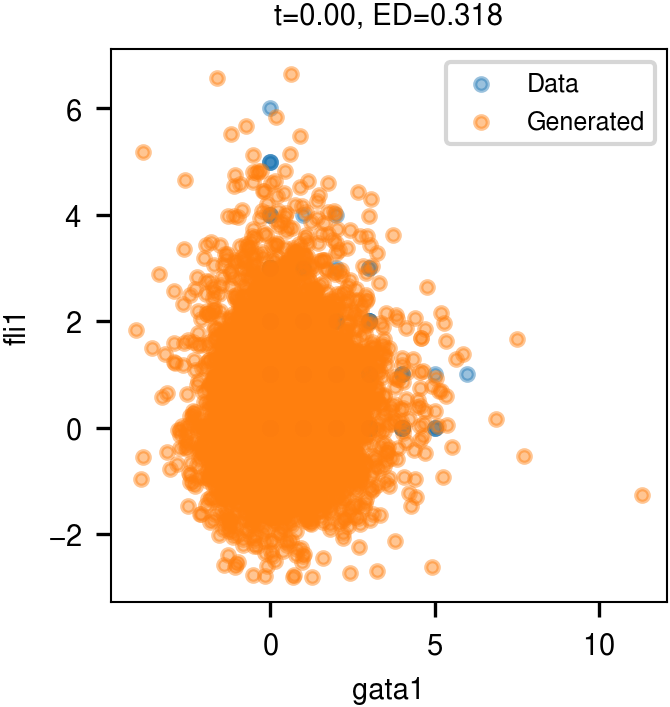

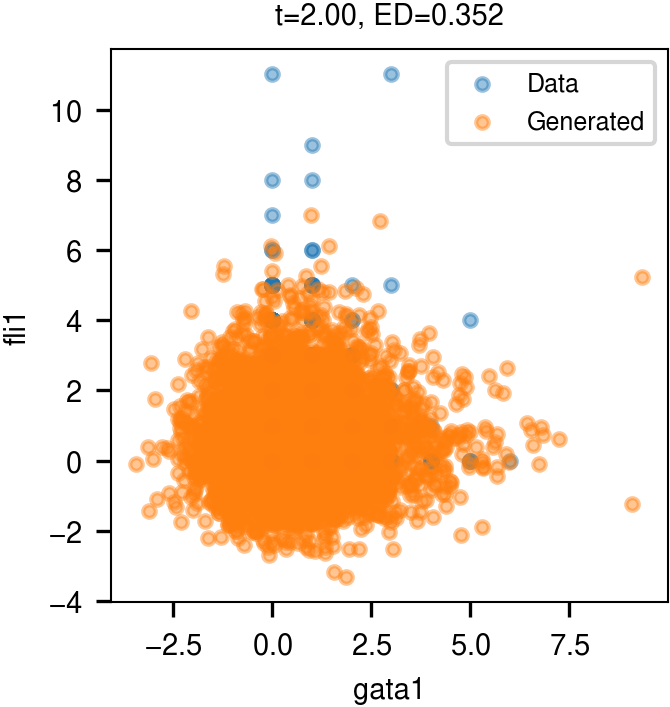

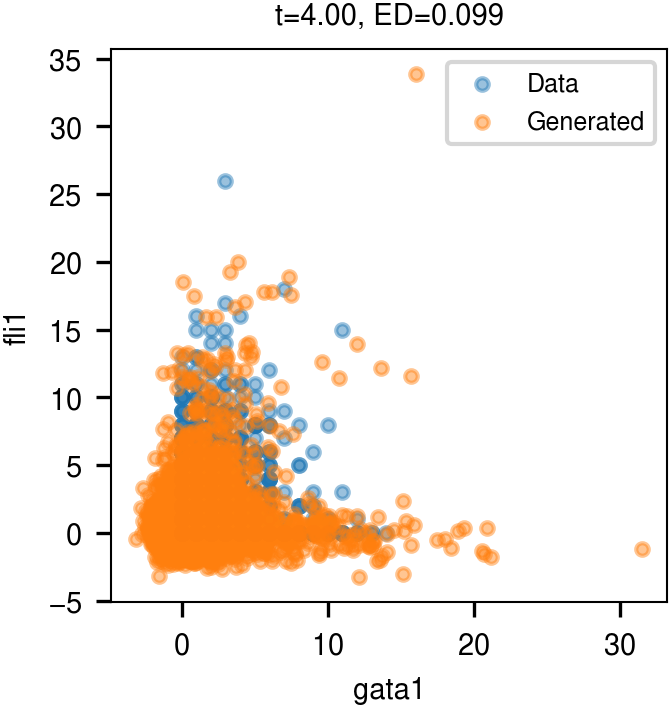

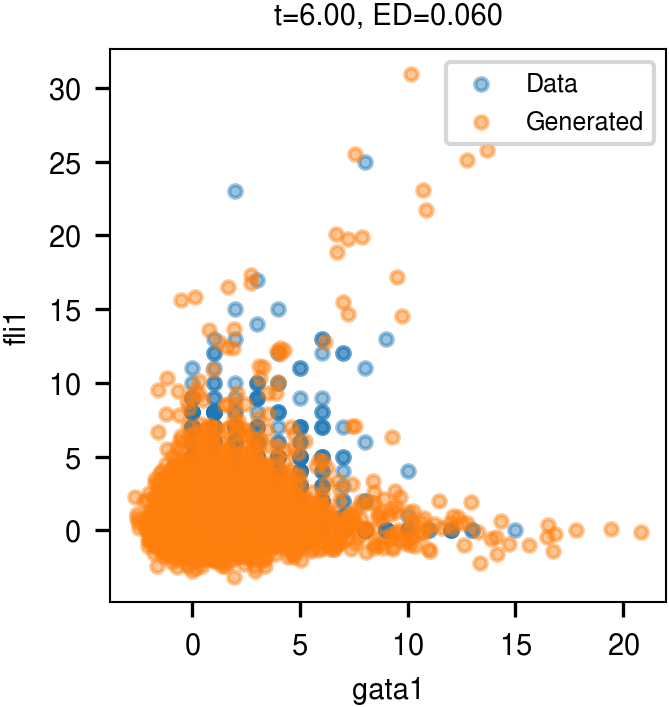

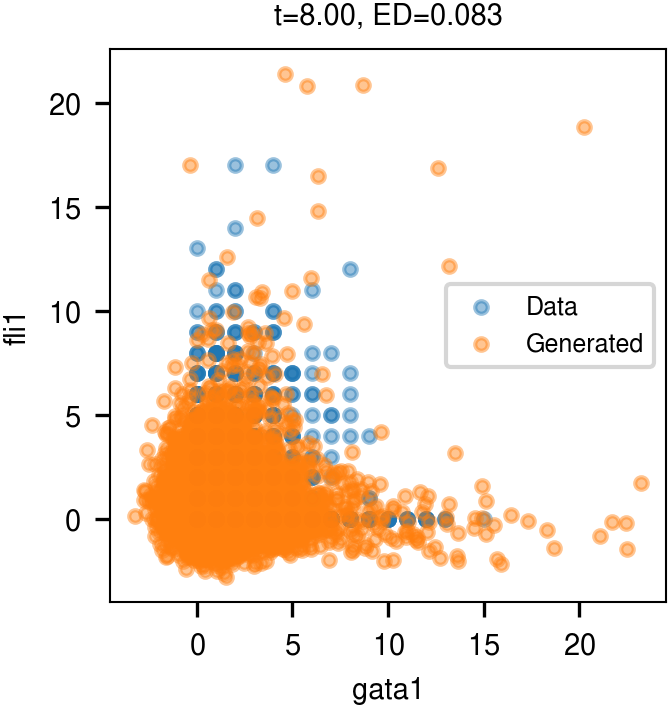

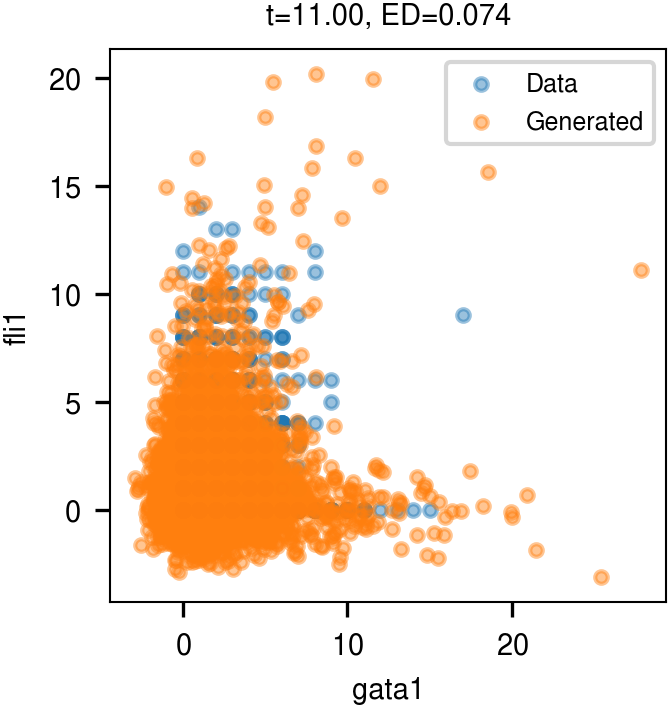

In [4]:
# Validate score model: generated samples vs observed snapshots + ED
times_eval = np.unique(X[:, -1])

gen = []
xks = []

X_gen = score_reg.sample(X)
ed_score = score_reg.score(X)

for k, t in enumerate(times_eval):

    xk = X[X[:, -1] == t]
    xk_gen = X_gen[X_gen[:, -1] == t]
    fig, ax = plt.subplots()
    ax.scatter(xk[:, 0], xk[:, 1], alpha=0.45, label='Data')
    ax.scatter(xk_gen[:, 0], xk_gen[:, 1], alpha=0.45, label='Generated')
    ax.set_title(f't={t:.2f}, ED={ed_score[k]:.3f}')
    ax.set_xlabel(genes[0])
    ax.set_ylabel(genes[1])
    ax.legend(loc='best')

plt.show()


In [ ]:
flow_regs = {}
flow_params = {}
flow_params['f_solver_kwargs'] = {'nb': 1, 'fac': 2, 'interp': LinearInterpolant()}

model_classes = {
    'cle': CLEFlow,
    'additive': AdditiveFlow,
    'multiplicative': MultiplicativeFlow,
    'autonomous_ode': AutonomousODEFlow,
}

for model_name in ['cle', 'additive', 'multiplicative', 'autonomous_ode']:

    flow_params['f_model'] = model_classes[model_name]
    flow_reg = make_flow_estimator(ndim=ndim, 
                                   params=flow_params, 
                                   device=device, 
                                   seed=seed)
    flow_reg.flow.score = freeze_dsm_score(score_reg.model_, 
                                           noise_lvl=score_reg.noise_lvl_)

    flow_reg.fit(X)
    flow_regs[model_name] = flow_reg


pfm_paper: 100%|██████████| 3000/3000 [00:11<00:00, 250.40it/s, loss=2.362e-02, lr=1.00e-05]


In [ ]:
# Run inferred models from NatComm t0 to the last train time
train_times = np.asarray(times, dtype=float)
t0_train = float(train_times[0])
tT_train = float(train_times[-1])
X0_train = np.hstack([samples[0, :, :ndim], t0_train * np.ones((samples.shape[1], 1))])

gen_natcomm_last = {}
for model_name, reg in flow_regs.items():
    gen_natcomm_last[model_name] = reg.sample(
        X0_train,
        Dt=tT_train,
        stoch=True,
        dt=0.005,
        pos=True,
    )
    print(model_name, gen_natcomm_last[model_name].shape)



cle (6000, 24)
additive (6000, 24)
multiplicative (6000, 24)
autonomous_ode (6000, 24)


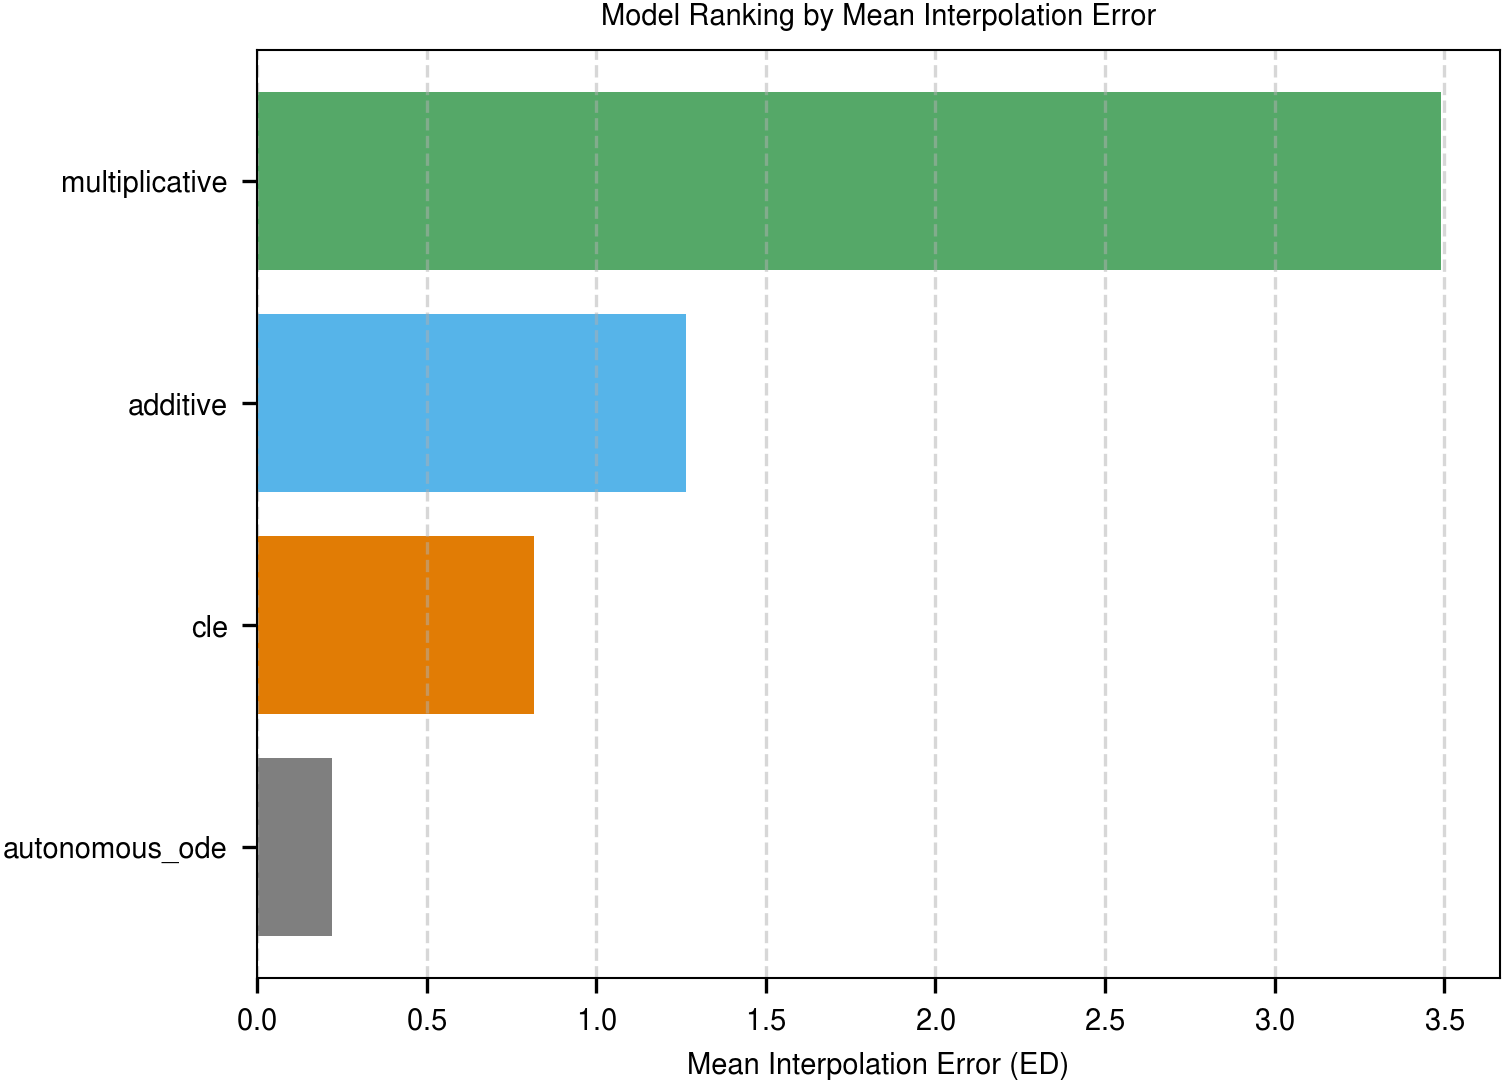

In [21]:
# Stochastic interpolation
import matplotlib.pyplot as plt

t_ex = np.sort(np.unique(X[:, -1]))
t0_ex = t_ex[0]
X0_ex = X[np.isclose(X[:, -1], t0_ex)]
interp_errors = {}
for name, reg in flow_regs.items():
    ed = []
    for ty in t_ex[1:]:
        y_t = X[np.isclose(X[:, -1], ty)]
        ed.append(reg.score(X0_ex, y_t, stoch=True, dt=1e-2)[0])
    interp_errors[name] = np.asarray(ed)

mean_interp_errors = {name: float(np.mean(ed)) for name, ed in interp_errors.items()}

sorted_items = sorted(mean_interp_errors.items(), key=lambda x: x[1])
methods_sorted, means_sorted = zip(*sorted_items)

base_colors = {
    'cle': '#E17C05',
    'additive': '#56B4E9',
    'multiplicative': '#55A868',
}
colors_sorted = [base_colors.get(m, '#7F7F7F') for m in methods_sorted]

fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.barh(methods_sorted, means_sorted, color=colors_sorted)
ax.set_xlabel('Mean Interpolation Error (ED)')
ax.set_title('Model Ranking by Mean Interpolation Error')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



### Kaggle generalization from HSC initial condition


In [22]:
# Load Kaggle multiome data and keep HSC/HSPC cells at first time point
path_kaggle = '/mnt/home/vchardes/ceph/datasets/HSC_data/kaggle_multiome_RNA_new_cleaned.h5ad'
nsamples_kaggle = 16000

samples_kaggle, times_kaggle, ind_array_kaggle, cell_types_kaggle = load_data(
    path=path_kaggle,
    nsamples=nsamples_kaggle,
    genes=genes,
    time_key='day',
    cell_type_key='cell_type',
    seed=seed,
)

kaggle_categories = list(cell_types_kaggle.cat.categories)
kaggle_ct_to_int = {ct: i for i, ct in enumerate(kaggle_categories)}
hsc_code = kaggle_ct_to_int['HSPC']
ind_hsc0 = np.where(ind_array_kaggle[0] == hsc_code)[0]
HSC_kaggle = samples_kaggle[0, ind_hsc0, :ndim]

print('Kaggle times:', times_kaggle)
print('Kaggle categories:', kaggle_categories)
print('HSPC/HSC cells at first kaggle time:', HSC_kaggle.shape[0])


Kaggle times: [ 2  3  4  7 10]
Kaggle categories: ['B cell', 'Erythroid cell', 'Granulocyte monocyte progenitor', 'HSPC', 'MEMP', 'Megakaryocyte', 'Megakaryocyte progenitor cell', 'Monocyte', 'Myeloid progenitor', 'Mast', 'Basophil', 'Eosinophil']
HSPC/HSC cells at first kaggle time: 10074


In [ ]:
# Run inferred models from kaggle HSC at first time to last kaggle time
t0_kaggle = 0#float(times_kaggle[0])
tT_kaggle = float(times_kaggle[-1] - times_kaggle[0])
X0_kaggle = np.hstack([HSC_kaggle, t0_kaggle * np.ones((HSC_kaggle.shape[0], 1))])

gen_kaggle_last = {}
for model_name, reg in flow_regs.items():
    gen_kaggle_last[model_name] = reg.sample(
        X0_kaggle,
        Dt = 1*float(tT_kaggle - t0_kaggle),
        stoch=True,
        dt=0.005,
        pos=True,
    )


/mnt/home/vchardes/.local/share/venvs/score/lib/python3.10/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


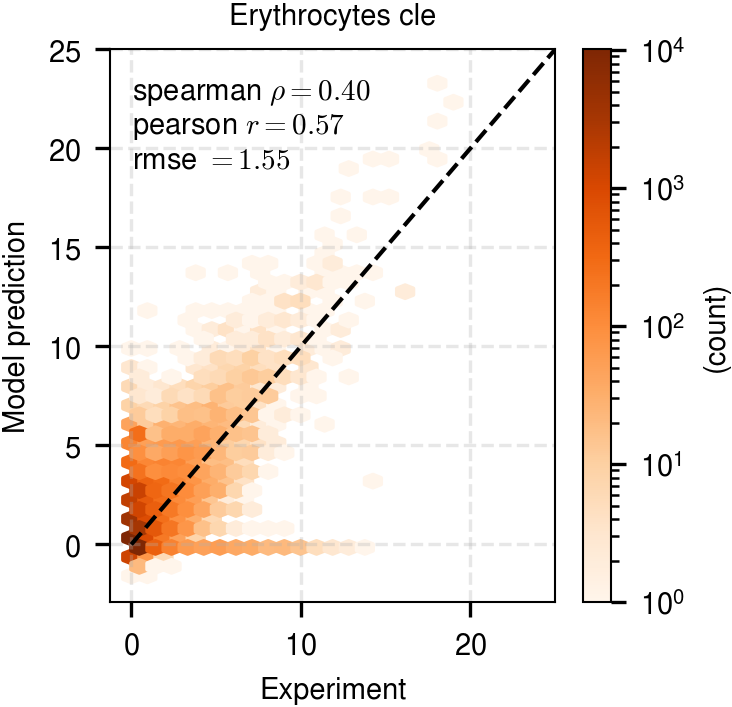

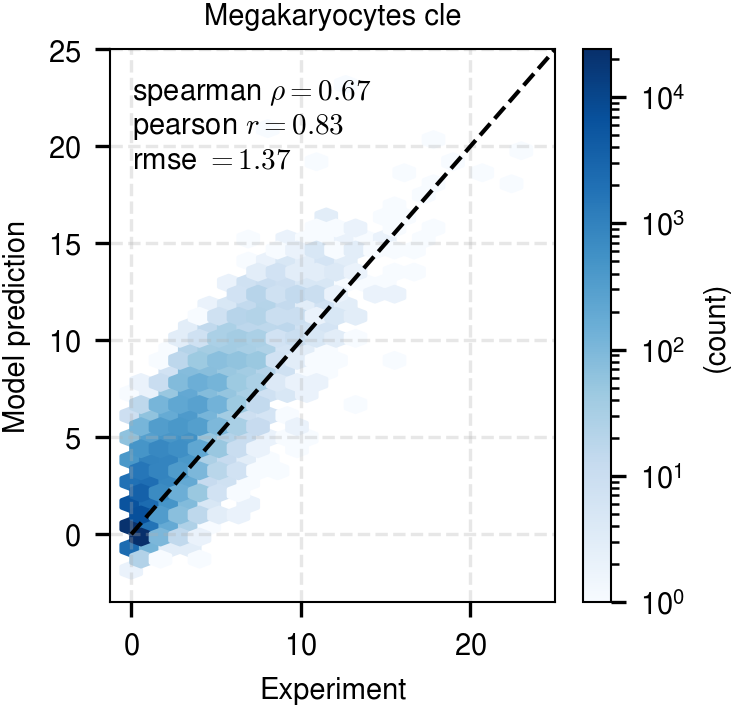

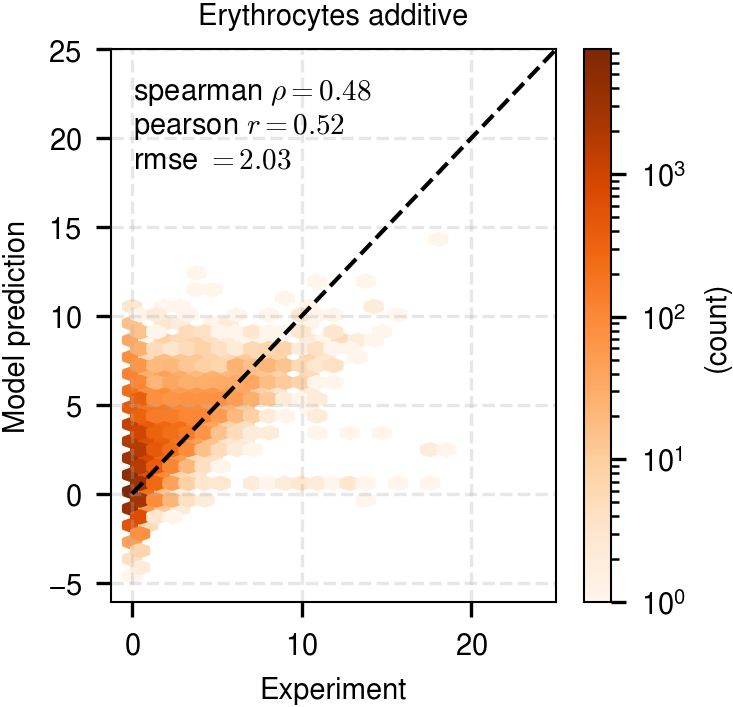

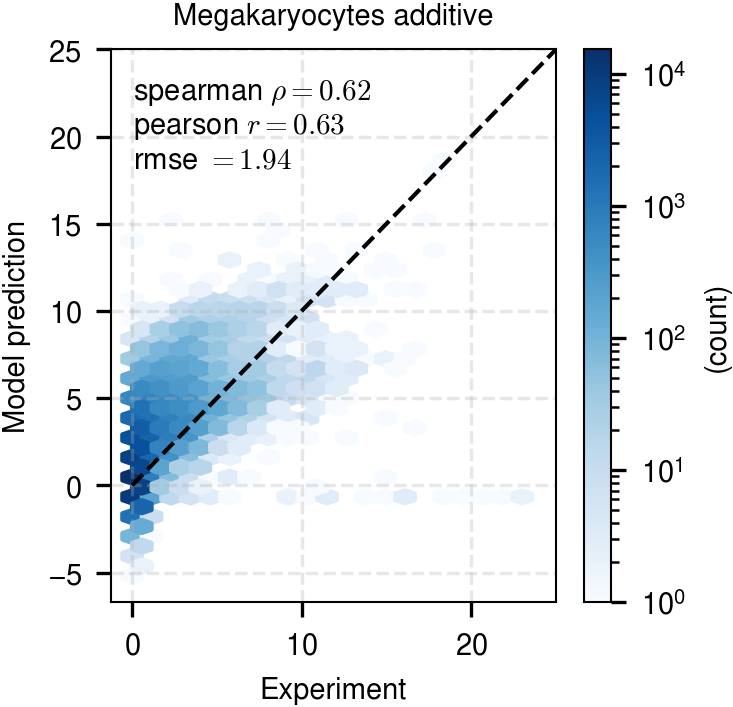

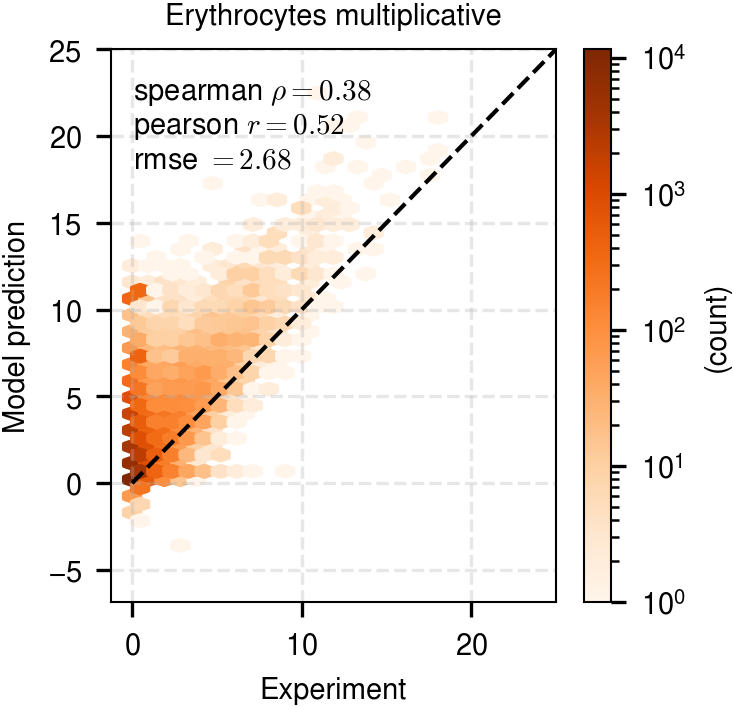

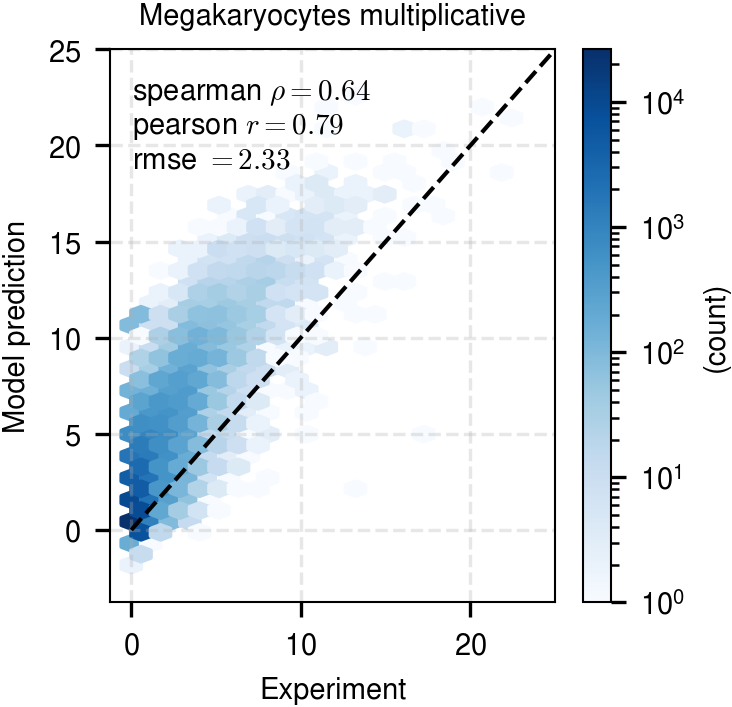

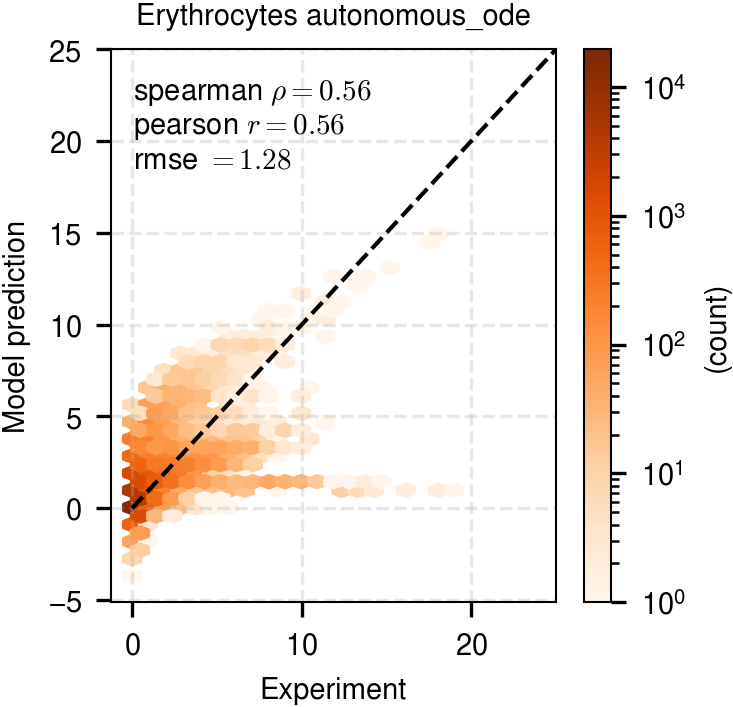

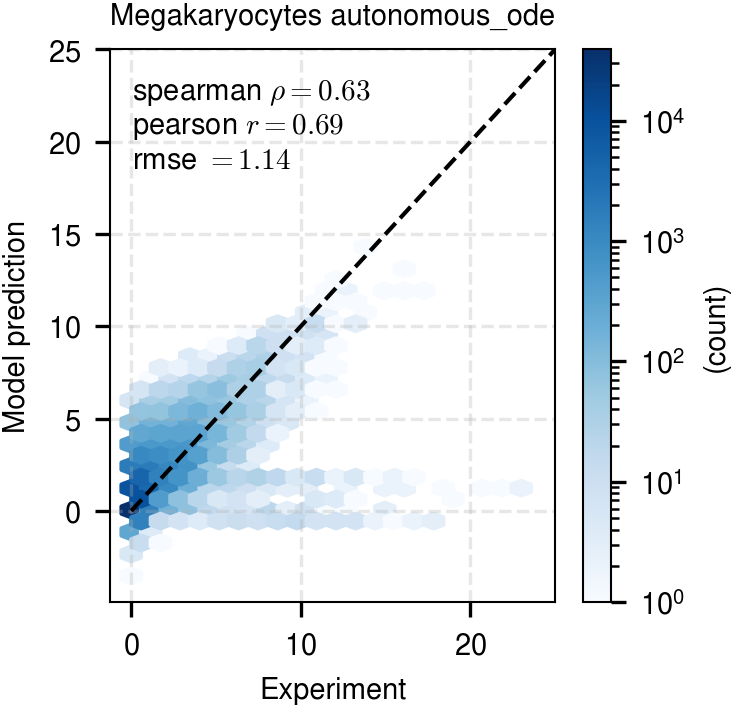

In [24]:
# Final-time generalization: per-model hexbin + correlation computation
import matplotlib.pyplot as plt
from pfi.utils.data import assign_OT, compute_correlations

train_categories = list(cell_types.cat.categories)
train_ct_to_int = {ct: i for i, ct in enumerate(train_categories)}
ind_Ery = np.where((ind_array[-1,] == train_ct_to_int['Ery1']) | (ind_array[-1,] == train_ct_to_int['Ery2']))[0]
ind_Meg = np.where((ind_array[-1,] == train_ct_to_int['Mk1']) | (ind_array[-1,] == train_ct_to_int['Mk2']))[0]
groups = {'erythrocytes': ind_Ery, 'megakaryocytes': ind_Meg}

train_last = samples[-1, :, :ndim]
comparison = {}
xmax = 25
ymax = 25

for model_name in flow_regs.keys():
    x_ref_test, y_test = assign_OT(train_last, gen_kaggle_last[model_name][:, :ndim])
    x_ref_train, y_train = assign_OT(train_last, gen_natcomm_last[model_name][:, :ndim])

    comparison[model_name] = {}
    for group_name, inds in groups.items():
        comparison[model_name][group_name] = {
            'test': compute_correlations(x_ref_test[inds], y_test[inds]),
            'train': compute_correlations(x_ref_train[inds], y_train[inds]),
        }

    for group_name, inds, label, cmap_ in [
        ('erythrocytes', ind_Ery, 'Erythrocytes', 'Oranges'),
        ('megakaryocytes', ind_Meg, 'Megakaryocytes', 'Blues'),
    ]:
            
        fig, ax = plt.subplots(1, 1)

        all_xt = x_ref_test[inds].reshape(-1)
        all_xtp1 = y_test[inds].reshape(-1)

        x_span = all_xt.max() - all_xt.min()
        y_span = all_xtp1.max() - all_xtp1.min()
        nx = 20
        ny = max(1, int(round(nx * y_span / x_span))) if x_span > 0 else nx

        hb = ax.hexbin(all_xt, all_xtp1, gridsize=(nx, ny), cmap=cmap_, bins='log')
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label('(count)')

        metrics = comparison[model_name][group_name]['test']
        ax.plot([0, xmax], [0, ymax], 'k--', lw=1)
        ax.set_xlim(xmax = xmax)
        ax.set_ylim(ymax = ymax)
        
        ax.set_xlabel('Experiment')
        ax.set_ylabel('Model prediction')
        ax.set_title(label + ' %s' % model_name)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.text(
            0.05,
            0.95,
            rf"spearman $\rho = {metrics['spearman']:.2f}$"
            + "\n"
            + rf"pearson $r = {metrics['pearson']:.2f}$"
            + "\n"
            + rf"rmse $= {metrics['rmse_l2']:.2f}$",
            transform=ax.transAxes,
            ha='left',
            va='top',
        )

    plt.show()

Pearson (test vs train):
cle | Ery: 0.568 vs 0.550 | Meg: 0.834 vs 0.839
additive | Ery: 0.517 vs 0.536 | Meg: 0.627 vs 0.595
multiplicative | Ery: 0.518 vs 0.602 | Meg: 0.786 vs 0.797
autonomous_ode | Ery: 0.556 vs 0.810 | Meg: 0.688 vs 0.850


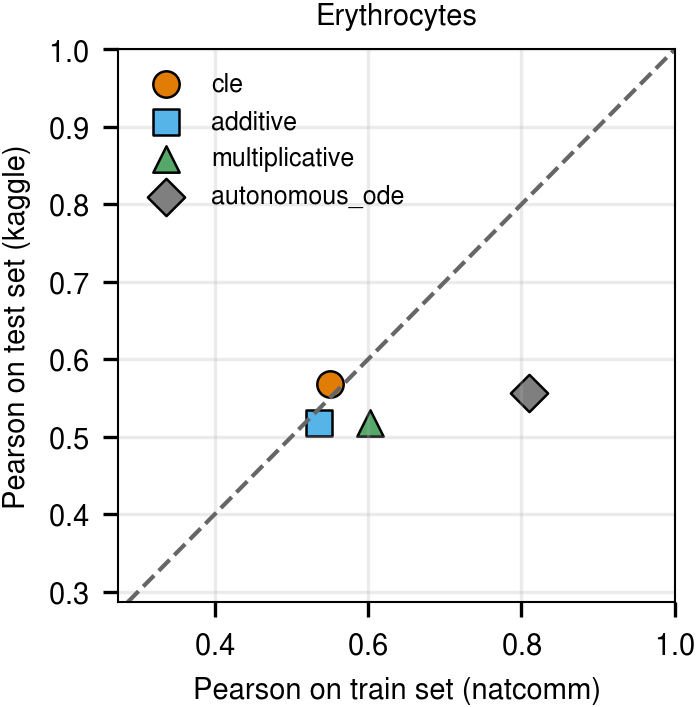

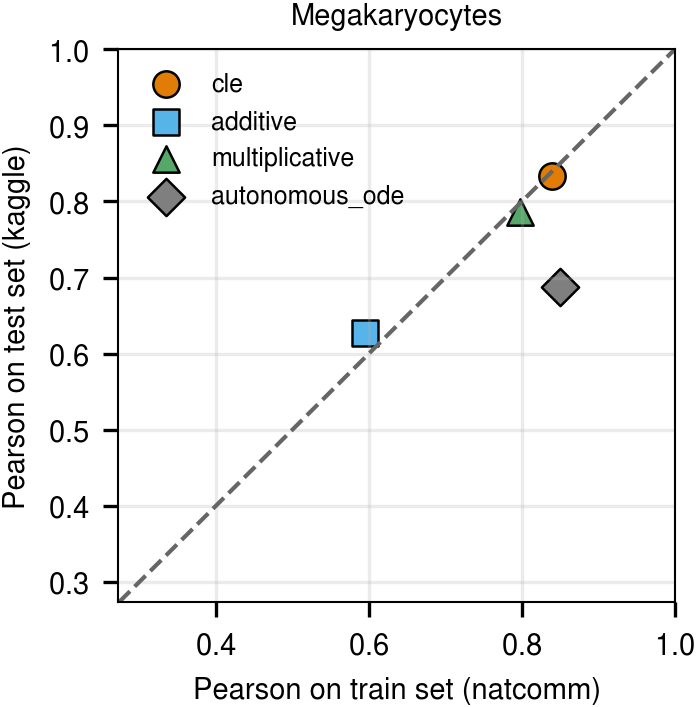

In [25]:
print('Pearson (test vs train):')
for model_name, scores in comparison.items():
    print(
        model_name,
        '| Ery:',
        f"{scores['erythrocytes']['test']['pearson']:.3f}",
        'vs',
        f"{scores['erythrocytes']['train']['pearson']:.3f}",
        '| Meg:',
        f"{scores['megakaryocytes']['test']['pearson']:.3f}",
        'vs',
        f"{scores['megakaryocytes']['train']['pearson']:.3f}",
    )

style = {
    'cle': {'color': '#E17C05', 'marker': 'o'},
    'additive': {'color': '#56B4E9', 'marker': 's'},
    'multiplicative': {'color': '#55A868', 'marker': '^'},
    'autonomous_ode': {'color': '#7F7F7F', 'marker': 'D'},
}

for group_name, title in [
    ('erythrocytes', 'Erythrocytes'),
    ('megakaryocytes', 'Megakaryocytes'),
]:
    fig, ax = plt.subplots(1, 1)

    for model_name, scores in comparison.items():
        cfg = style.get(model_name, {'color': 'black', 'marker': 'o'})
        ax.scatter(
            scores[group_name]['train']['pearson'],
            scores[group_name]['test']['pearson'],
            c=cfg['color'],
            marker=cfg['marker'],
            edgecolor='k',
            s = 40,
            linewidth=0.6,
            label=model_name,
        )

    ax.axline((0.3, 0.3), slope=1.0, linestyle='--', color='0.4')
    ax.set_xlim(xmax=1)
    ax.set_ylim(ymax=1)
    ax.set_title(title)
    ax.set_xlabel('Pearson on train set (natcomm)')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', frameon=False)
    ax.set_ylabel('Pearson on test set (kaggle)')
plt.show()

